In [33]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
import xarray as xr
import numpy as np
import xgcm
import matplotlib.pyplot as plt
from load_example_ecco_grid import * 
import xbudget
print("xarray:",  xr.__version__)
print("xgcm:", xgcm.__version__)

xbudget_dict = xbudget.load_yaml("ECCOV4r4.yaml").copy()

xarray: 2025.10.1
xgcm: 0.9.0


In [36]:
ecco_budget = xr.open_mfdataset("../data/data/ECCO_budget_terms.zarr").chunk({"k_l":-1, "tile":-1}).fillna(0.0)

grid = construct_grid(ecco_budget)

dt = grid._ds["time_bounds"].diff("time_bounds").rename({"time_bounds":"time"})
dt = dt.dt.total_seconds() #nice! 

xbudget.collect_budgets(grid, xbudget_dict)
import json
print(json.dumps(xbudget_dict['mass'], sort_keys=True, indent=4))

/Users/anthonymeza/Library/CloudStorage/OneDrive-MassachusettsInstituteofTechnology/Documents/GitHub/xbudget/xbudget/collect.py:231: UserWarning: Variable mass_rhs_sum is missing from the dataset `ds`, so it is being skipped. To suppress this warning, remove mass_rhs_sum from the `xbudget_dict`.
  warnings.warn(f"Variable {v_term} is missing from the dataset `ds`, so it is being skipped. To suppress this warning, remove {v_term} from the `xbudget_dict`.", UserWarning)
/Users/anthonymeza/Library/CloudStorage/OneDrive-MassachusettsInstituteofTechnology/Documents/GitHub/xbudget/xbudget/collect.py:231: UserWarning: Variable mass_rhs_sum_advection_sum is missing from the dataset `ds`, so it is being skipped. To suppress this warning, remove mass_rhs_sum_advection_sum from the `xbudget_dict`.
  warnings.warn(f"Variable {v_term} is missing from the dataset `ds`, so it is being skipped. To suppress this warning, remove {v_term} from the `xbudget_dict`.", UserWarning)
/Users/anthonymeza/Library

{
    "lambda": "density",
    "lhs": {
        "var": null
    },
    "rhs": {
        "sum": {
            "advection": {
                "sum": {
                    "interfacial": {
                        "product": {
                            "area": "rA",
                            "density": 1035.0,
                            "var": "mass_rhs_sum_advection_sum_interfacial_product",
                            "vertical_velocity_convergence": {
                                "difference": {
                                    "var": null,
                                    "vertical_seawater_velocity": "WVELMASS"
                                },
                                "var": null
                            }
                        },
                        "var": "mass_rhs_sum_advection_sum_interfacial"
                    },
                    "lateral_advection": {
                        "product": {
                            "lateral_divergence": {
   

In [29]:
def diff_1d_flux_llc90(w_flux, geometry):
    w_flux = w_flux.transpose('time','tile','k_l','j','i')
    w_flux_padded = w_flux.pad(pad_width={'k_l': (0, 1)}, 
                               mode='constant', 
                               constant_values=0) #all fluxes are zero at the bottom
    
    dw = w_flux_padded.diff("k_l")
    dw = dw.rename({'k_l': 'k'}).assign_coords(k=geometry['k'])
    return dw

    
def calc_1d_flux_convergence(w_flux, geometry):
    return diff_1d_flux_llc90(w_flux, geometry)
    
def calc_2d_flux_convergence(u_flux, v_flux, geometry):
    dudv = diff_2d_flux_llc90(u_flux, v_flux, geometry)

    flux_conv = -(dudv["X"] + dudv["Y"])
    
    if ("time" in flux_conv.coords):
        return flux_conv.transpose('time','tile','k','j','i')
    else:
        return flux_conv.transpose('tile','k','j','i')

def diff_2d_flux_llc90(u_flux, v_flux, geometry):
    """
    Manually compute the 2D divergence of fluxes on the LLC90 grid.
    This function mimics xgcm.diff_2d_vector but explicitly handles
    face connections and padding for the LLC topology.

    Parameters
    ----------
    flux_vector : dict
        A dictionary with keys 'X' and 'Y' containing xarray.DataArray
        objects for the U-flux (on i-face) and V-flux (on j-face),
        respectively.

    Returns
    -------
    dict
        A dictionary with keys 'X' and 'Y' for the differenced U and V
        flux components on C-grid points. You can combine these to get
        the divergence: dU/dx + dV/dy.
    """

    # ------------------------------------------------------------------------
    # 1) Pad arrays by one cell in the face dimension to prepare for diff
    # ------------------------------------------------------------------------

    # Pad u_flux along the i_g dimension (add a column of NaNs at the end)
    u_flux_padded = u_flux.pad(
        pad_width={'i_g': (0, 1)},
        mode='constant', constant_values=np.nan
    )
    # Ensure u_padded has a single chunk along i_g for unambiguous padding
    u_flux_padded = u_flux_padded.chunk({'i_g': u_flux_padded.sizes['i_g'] + 1})

    # Pad v_flux along the j_g dimension (add a row of NaNs at the end)
    v_flux_padded = v_flux.pad(
        pad_width={'j_g': (0, 1)},
        mode='constant', constant_values=np.nan
    )
    # Ensure v_padded has a single chunk along j_g
    v_flux_padded = v_flux_padded.chunk({'j_g': v_flux_padded.sizes['j_g'] + 1})

    # ------------------------------------------------------------------------
    # 2) Helper function to replace padded boundary values
    # ------------------------------------------------------------------------
    def da_replace_at_indices(da,indexing_dict,replace_values):
        # replace values in xarray DataArray using locations specified by indexing_dict
        array_data = da.data
        indexing_dict_bynum = {}
        for axis,dim in enumerate(da.dims):
            if dim in indexing_dict.keys():
                indexing_dict_bynum = {**indexing_dict_bynum,**{axis:indexing_dict[dim]}}
        ndims = len(array_data.shape)
        indexing_list = [':']*ndims
        for axis in indexing_dict_bynum.keys():
            indexing_list[axis] = indexing_dict_bynum[axis]
        indexing_str = ",".join(indexing_list)

        # using exec isn't ideal, but this works for both NumPy and Dask arrays
        exec('array_data['+indexing_str+'] = replace_values')

        return da

    # u flux padding
    for tile in range(0,3):
        u_flux_padded = da_replace_at_indices(u_flux_padded,{'tile':str(tile),'i_g':'-1'},\
                                              u_flux.isel(tile=tile+3,i_g=0).data)
    for tile in range(3,6):
        u_flux_padded = da_replace_at_indices(u_flux_padded,{'tile':str(tile),'i_g':'-1'},\
                                              v_flux.isel(tile=12-tile,j_g=0,i=slice(None,None,-1)).data)
    u_flux_padded = da_replace_at_indices(u_flux_padded,{'tile':'6','i_g':'-1'},\
                                          u_flux.isel(tile=7,i_g=0).data)
    for tile in range(7,9):
        u_flux_padded = da_replace_at_indices(u_flux_padded,{'tile':str(tile),'i_g':'-1'},\
                                              u_flux.isel(tile=tile+1,i_g=0).data)
    for tile in range(10,12):
        u_flux_padded = da_replace_at_indices(u_flux_padded,{'tile':str(tile),'i_g':'-1'},\
                                              u_flux.isel(tile=tile+1,i_g=0).data)

    # v flux padding
    for tile in range(0,2):
        v_flux_padded = da_replace_at_indices(v_flux_padded,{'tile':str(tile),'j_g':'-1'},\
                                              v_flux.isel(tile=tile+1,j_g=0).data)
    v_flux_padded = da_replace_at_indices(v_flux_padded,{'tile':'2','j_g':'-1'},\
                                          u_flux.isel(tile=6,j=slice(None,None,-1),i_g=0).data)
    for tile in range(3,6):
        v_flux_padded = da_replace_at_indices(v_flux_padded,{'tile':str(tile),'j_g':'-1'},\
                                              v_flux.isel(tile=tile+1,j_g=0).data)
    v_flux_padded = da_replace_at_indices(v_flux_padded,{'tile':'6','j_g':'-1'},\
                                          u_flux.isel(tile=10,j=slice(None,None,-1),i_g=0).data)
    for tile in range(7,10):
        v_flux_padded = da_replace_at_indices(v_flux_padded,{'tile':str(tile),'j_g':'-1'},\
                                              v_flux.isel(tile=tile+3,j_g=0).data)
    for tile in range(10,13):
        v_flux_padded = da_replace_at_indices(v_flux_padded,{'tile':str(tile),'j_g':'-1'},\
                                              u_flux.isel(tile=12-tile,j=slice(None,None,-1),i_g=0).data)

    # ------------------------------------------------------------------------
    # 5) Compute the finite differences on padded arrays
    # ------------------------------------------------------------------------

    # Difference along i_g then rename to i (C-point)
    du = u_flux_padded.diff('i_g')
    du = du.rename({'i_g': 'i'}).assign_coords(i=geometry['i'])

    # Difference along j_g then rename to j
    dv = v_flux_padded.diff('j_g')
    dv = dv.rename({'j_g': 'j'}).assign_coords(j=geometry['j'])

    # Return a dict matching xgcm's diff_2d_vector output
    return {'X': du, 'Y': dv}

def calc_2d_flux_convergence_ghost(grid, u_flux, v_flux):
    dudv = diff_2d_flux_llc90_ghost(grid, u_flux, v_flux)

    flux_conv = -(dudv["X"] + dudv["Y"])
    
    if ("time" in flux_conv.coords):
        return flux_conv.transpose('time','tile','k','j','i')
    else:
        return flux_conv.transpose('tile','k','j','i')

        
import numpy as np
import xarray as xr

def diff_2d_flux_llc90_ghost(grid, Fx, Fy, face_dim=None):
    if face_dim is None:
        keys = list(grid._face_connections.keys())
        if len(keys) != 1:
            raise ValueError("Provide face_dim when grid has multiple face-connection keys.")
        face_dim = keys[0]

    ds = grid._ds

    def _center_dim(ax):
        return grid.axes[ax].coords["center"]

    def _stag_dim(ax, da):
        c = [c for pos, c in grid.axes[ax].coords.items() if pos != "center" and c in da.dims]
        if len(c) != 1:
            raise ValueError("Flux difference inconsistent with finite volume discretization.")
        return c[0]

    Xc, Yc = _center_dim("X"), _center_dim("Y")
    Xs, Ys = _stag_dim("X", Fx), _stag_dim("Y", Fy)

    xs_new = int(Fx[Xs].isel({Xs: -1}).values) + 1
    ys_new = int(Fy[Ys].isel({Ys: -1}).values) + 1

    tiles = Fx[face_dim].values

    def ghost_X(t):
        t = int(t)
        if 0 <= t <= 2:
            g = Fx.sel({face_dim: t + 3}).isel({Xs: 0})
        elif 3 <= t <= 5:
            g = Fy.sel({face_dim: 12 - t}).isel({Ys: 0, Xc: slice(None, None, -1)}).rename({Xc: Yc}).assign_coords({Yc: ds[Yc]})
        elif t == 6:
            g = Fx.sel({face_dim: 7}).isel({Xs: 0})
        elif 7 <= t <= 8:
            g = Fx.sel({face_dim: t + 1}).isel({Xs: 0})
        elif 10 <= t <= 11:
            g = Fx.sel({face_dim: t + 1}).isel({Xs: 0})
        else:
            g = xr.full_like(Fx.sel({face_dim: t}).isel({Xs: 0}), np.nan)
        return g.expand_dims({face_dim: [t], Xs: [xs_new]})

    def ghost_Y(t):
        t = int(t)
        if 0 <= t <= 1:
            g = Fy.sel({face_dim: t + 1}).isel({Ys: 0})
        elif t == 2:
            g = Fx.sel({face_dim: 6}).isel({Xs: 0, Yc: slice(None, None, -1)}).rename({Yc: Xc}).assign_coords({Xc: ds[Xc]})
        elif 3 <= t <= 5:
            g = Fy.sel({face_dim: t + 1}).isel({Ys: 0})
        elif t == 6:
            g = Fx.sel({face_dim: 10}).isel({Xs: 0, Yc: slice(None, None, -1)}).rename({Yc: Xc}).assign_coords({Xc: ds[Xc]})
        elif 7 <= t <= 9:
            g = Fy.sel({face_dim: t + 3}).isel({Ys: 0})
        elif 10 <= t <= 12:
            g = Fx.sel({face_dim: 12 - t}).isel({Xs: 0, Yc: slice(None, None, -1)}).rename({Yc: Xc}).assign_coords({Xc: ds[Xc]})
        else:
            g = xr.full_like(Fy.sel({face_dim: t}).isel({Ys: 0}), np.nan)
        return g.expand_dims({face_dim: [t], Ys: [ys_new]})

    gx = xr.concat([ghost_X(t) for t in tiles], dim=face_dim, coords="minimal", compat="override", join="override")
    gy = xr.concat([ghost_Y(t) for t in tiles], dim=face_dim, coords="minimal", compat="override", join="override")

    Fx_p = xr.concat([Fx, gx], dim=Xs, coords="minimal", compat="override", join="override").chunk({Xs: -1})
    Fy_p = xr.concat([Fy, gy], dim=Ys, coords="minimal", compat="override", join="override").chunk({Ys: -1})

    return {
        "X": Fx_p.diff(Xs).rename({Xs: Xc}).assign_coords({Xc: ds[Xc]}),
        "Y": Fy_p.diff(Ys).rename({Ys: Yc}).assign_coords({Yc: ds[Yc]}),
    }


In [30]:
grid._ds["WVELMASS_conv"] = calc_1d_flux_convergence((grid._ds["WVELMASS"] * grid._ds["rA"]).fillna(0.0).chunk({grid.axes["Z"].coords["left"]:-1}), grid._ds)
grid._ds["WVELMASS_conv"] = grid._ds["WVELMASS_conv"]  / grid._ds["rA"]
grid._ds["WVELMASS_conv"] = grid._ds["WVELMASS_conv"].sum("k")

Fx = grid._ds["UVELMASS"] * grid._ds["dyG"] *  grid._ds["drF"]
Fy = grid._ds["VVELMASS"] * grid._ds["dxG"] *  grid._ds["drF"]

# keep the face dims unchunked (or at least not fragmented) for padding
Fx = Fx.chunk({"tile":-1, "i_g": -1, "j": -1}).fillna(0.0)
Fy = Fy.chunk({"tile":-1, "i": -1, "j_g": -1}).fillna(0.0)

grid._ds["HVELMASS_conv"] = calc_2d_flux_convergence(Fx, Fy, grid._ds)
grid._ds["HVELMASS_conv"] = (grid._ds["HVELMASS_conv"]).sum("k")
grid._ds["HVELMASS_conv"] = (grid._ds["HVELMASS_conv"])  / grid._ds["rA"]

divF = xbudget.diff_2d_flux_llc90(grid, Fx, Fy)

grid._ds["HVELMASS_conv_ghost"] = -(divF["X"] + divF["Y"])
grid._ds["HVELMASS_conv_ghost"] = (grid._ds["HVELMASS_conv_ghost"]).sum("k")
grid._ds["HVELMASS_conv_ghost"] = (grid._ds["HVELMASS_conv_ghost"])  / grid._ds["rA"]

In [31]:
deta_dt = grid._ds["ETAN_bounds"].diff("time_bounds").rename({"time_bounds":"time"}) / dt

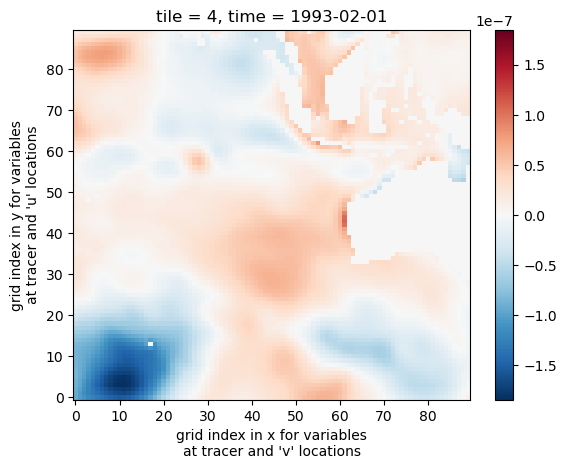

In [32]:
deta_dt.isel(time = 0, tile = 4).plot()